# [LAB-02] 8. DBSCAN 튜닝・평가 - 연습문제

## 준비작업

### 라이브러리 참조

In [10]:
from jussam import load_data
from helpers import *
from pandas import DataFrame, crosstab
import numpy as np
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
from sklearn.metrics import adjusted_rand_score

## 📚 그 반경 2.0은 어디서 나온 숫자인가 — 근거를 대라

### 당신은 반경 2.0으로 특이 거래처 15곳을 걸러낸 그 담당자입니다.

지난 보고에서 당신은 밀집도로 거래처 440곳을 훑어 어디에도 속하지 못한 15곳을 찾아냈고, 이들을 무리에서 빼는 대신 따로 관리하자는 안을 올렸습니다. 보고서를 읽던 팀장이 표의 한 줄에 밑줄을 긋고 되묻습니다. "반경 2.0. 이 숫자는 어디서 나왔나. 노이즈 비율이 5% 밑으로 처음 떨어져서 골랐다고 했지. 그럼 기준을 3%로 잡았으면 2.5를 골랐을 것 아닌가. 기준을 바꾸면 답도 바뀌는 숫자를 근거라고 부를 수는 없다."

그래서 이번에는 반경을 눈대중으로 고르지 않고 **데이터에서 끌어냅니다.** 각 거래처에서 가까운 이웃 몇 곳까지의 거리를 재어 작은 순으로 늘어놓으면, 끝부분에서 거리가 급격히 치솟는 구간이 나타납니다. 그 치솟기 직전의 거리가 곧 반경의 근거입니다. 데이터 준비는 지난번과 같습니다 — 채널·지역은 빼고, 큰 거래처 때문에 치우친 지출액을 완만하게 만든 뒤 표준화합니다. 다만 변수가 6개이므로 **한 무리로 인정할 최소 이웃 수는 10으로 고정**합니다.

거리 분포에서 반경을 직접 끌어낸 다음, 그 반경으로 다시 나눈 결과가 지난번 보고와 얼마나 달라지는지까지 확인하세요.

### 💻 코드 작성

#### 데이터 가져오기 + 전처리 (지난번과 동일)

In [11]:
origin = load_data("wholesale_customers")

df1 = origin.drop(columns=["Channel", "Region"])

# 몇몇 큰 거래처 때문에 한쪽으로 심하게 치우친 금액을 완만하게 만든 뒤 표준화한다
df2 = my_prep.log_transform(df1, log_columns=list(df1.columns), verbose=False)
sdf = my_prep.scaling(df2, method="standard", verbose=False)

print(f"군집분석에 사용할 변수 개수: {sdf.shape[1]}개")

sdf.head()

📚 이 데이터 세트는 도매 유통업체의 고객 정보를 담고 있습니다. 다양한 제품 카테고리에 대한 연간 지출액(mu, 화폐 단위)을 포함합니다. (출처: https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set)

컬럼명            의미                  설명
----------------  --------------------  --------------------------------------------------------------------------------------------
Channel           유통 채널             고객의 거래 채널을 나타냄. 주로 Horeca(호텔·레스토랑·카페) 또는 Retail(소매점) 구분에 사용됨
Region            지역                  고객이 속한 지리적 지역 구분 변수. 특정 국가 내의 권역 정보
Fresh             신선식품 구매액       육류, 채소, 과일 등 신선식품 카테고리에 대한 연간 구매 금액
Milk              유제품 구매액         우유, 치즈, 요거트 등 유제품 카테고리에 대한 연간 구매 금액
Grocery           식료품 구매액         가공식품, 일반 식료품 등 장기 보관 식품 카테고리 구매 금액
Frozen            냉동식품 구매액       냉동 육류, 냉동 가공식품 등 냉동식품 카테고리 구매 금액
Detergents_Paper  세제·종이류 구매액    세제, 화장지, 키친타월 등 생활 소모품 구매 금액
Delicassen        즉석·가공식품 구매액  즉석식품, 델리 식품, 가공 반찬류 등의 구매 금액

군집분석에 사용할 변수 개수: 6개


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.485,0.976,0.439,-1.508,0.643,0.408
1,0.089,0.991,0.650,0.135,0.764,0.624
2,0.018,0.891,0.454,0.377,0.802,1.758
3,0.516,-0.958,-0.084,1.140,-0.324,0.629
4,0.877,0.440,0.395,0.757,0.405,1.442


#### 최소 이웃 수 고정

In [12]:
# 변수가 6개이므로 권장 구간(5~10개 변수 → 8~15)의 중간값인 10으로 고정한다
min_samples = 10
k = min_samples

print(f"min_samples = {min_samples}")

min_samples = 10


#### 각 거래처에서 k번째 이웃까지의 거리 구하기

In [13]:
# 각 거래처에서 가까운 순서로 k곳의 이웃을 찾는다
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(sdf)

# distance[i] = i번째 거래처에서 이웃들까지의 거리 (가까운 순, 자기 자신 포함)
distance, indices = neighbors.kneighbors(sdf)

# 마지막 열(= k번째 이웃까지의 거리)만 뽑아서 작은 순으로 정렬
target = np.sort(distance[:, k - 1])

print(f"가장 빽빽한 거래처: {target[0]:.4f}")
print(f"가장 외톨이인 거래처: {target[-1]:.4f}")
print(f"중앙값: {np.median(target):.4f}")

가장 빽빽한 거래처: 0.6492
가장 외톨이인 거래처: 5.4196
중앙값: 1.0978


#### 꺾이는 지점 찾기 (Elbow Point)

In [14]:
# 정렬한 거리 곡선은 오른쪽 위로 치솟는 모양이므로 convex + increasing
kl = KneeLocator(range(0, len(target)), target,
                 curve="convex", direction="increasing")

eps = kl.elbow_y     # 꺾이는 지점의 '거리' → 이것이 반경의 근거
point = kl.elbow     # 꺾이는 지점의 '순서'

print(f"데이터에서 끌어낸 반경: {eps:.4f}")
print(f"꺾이는 위치: {point}번째 거래처 (전체 {len(target)}곳 중)")
print(f"반경보다 이웃이 멀리 있는 거래처: {int((target > eps).sum())}곳")

데이터에서 끌어낸 반경: 2.3202
꺾이는 위치: 412번째 거래처 (전체 440곳 중)
반경보다 이웃이 멀리 있는 거래처: 27곳


#### 거리 분포 시각화 (k-distance plot)

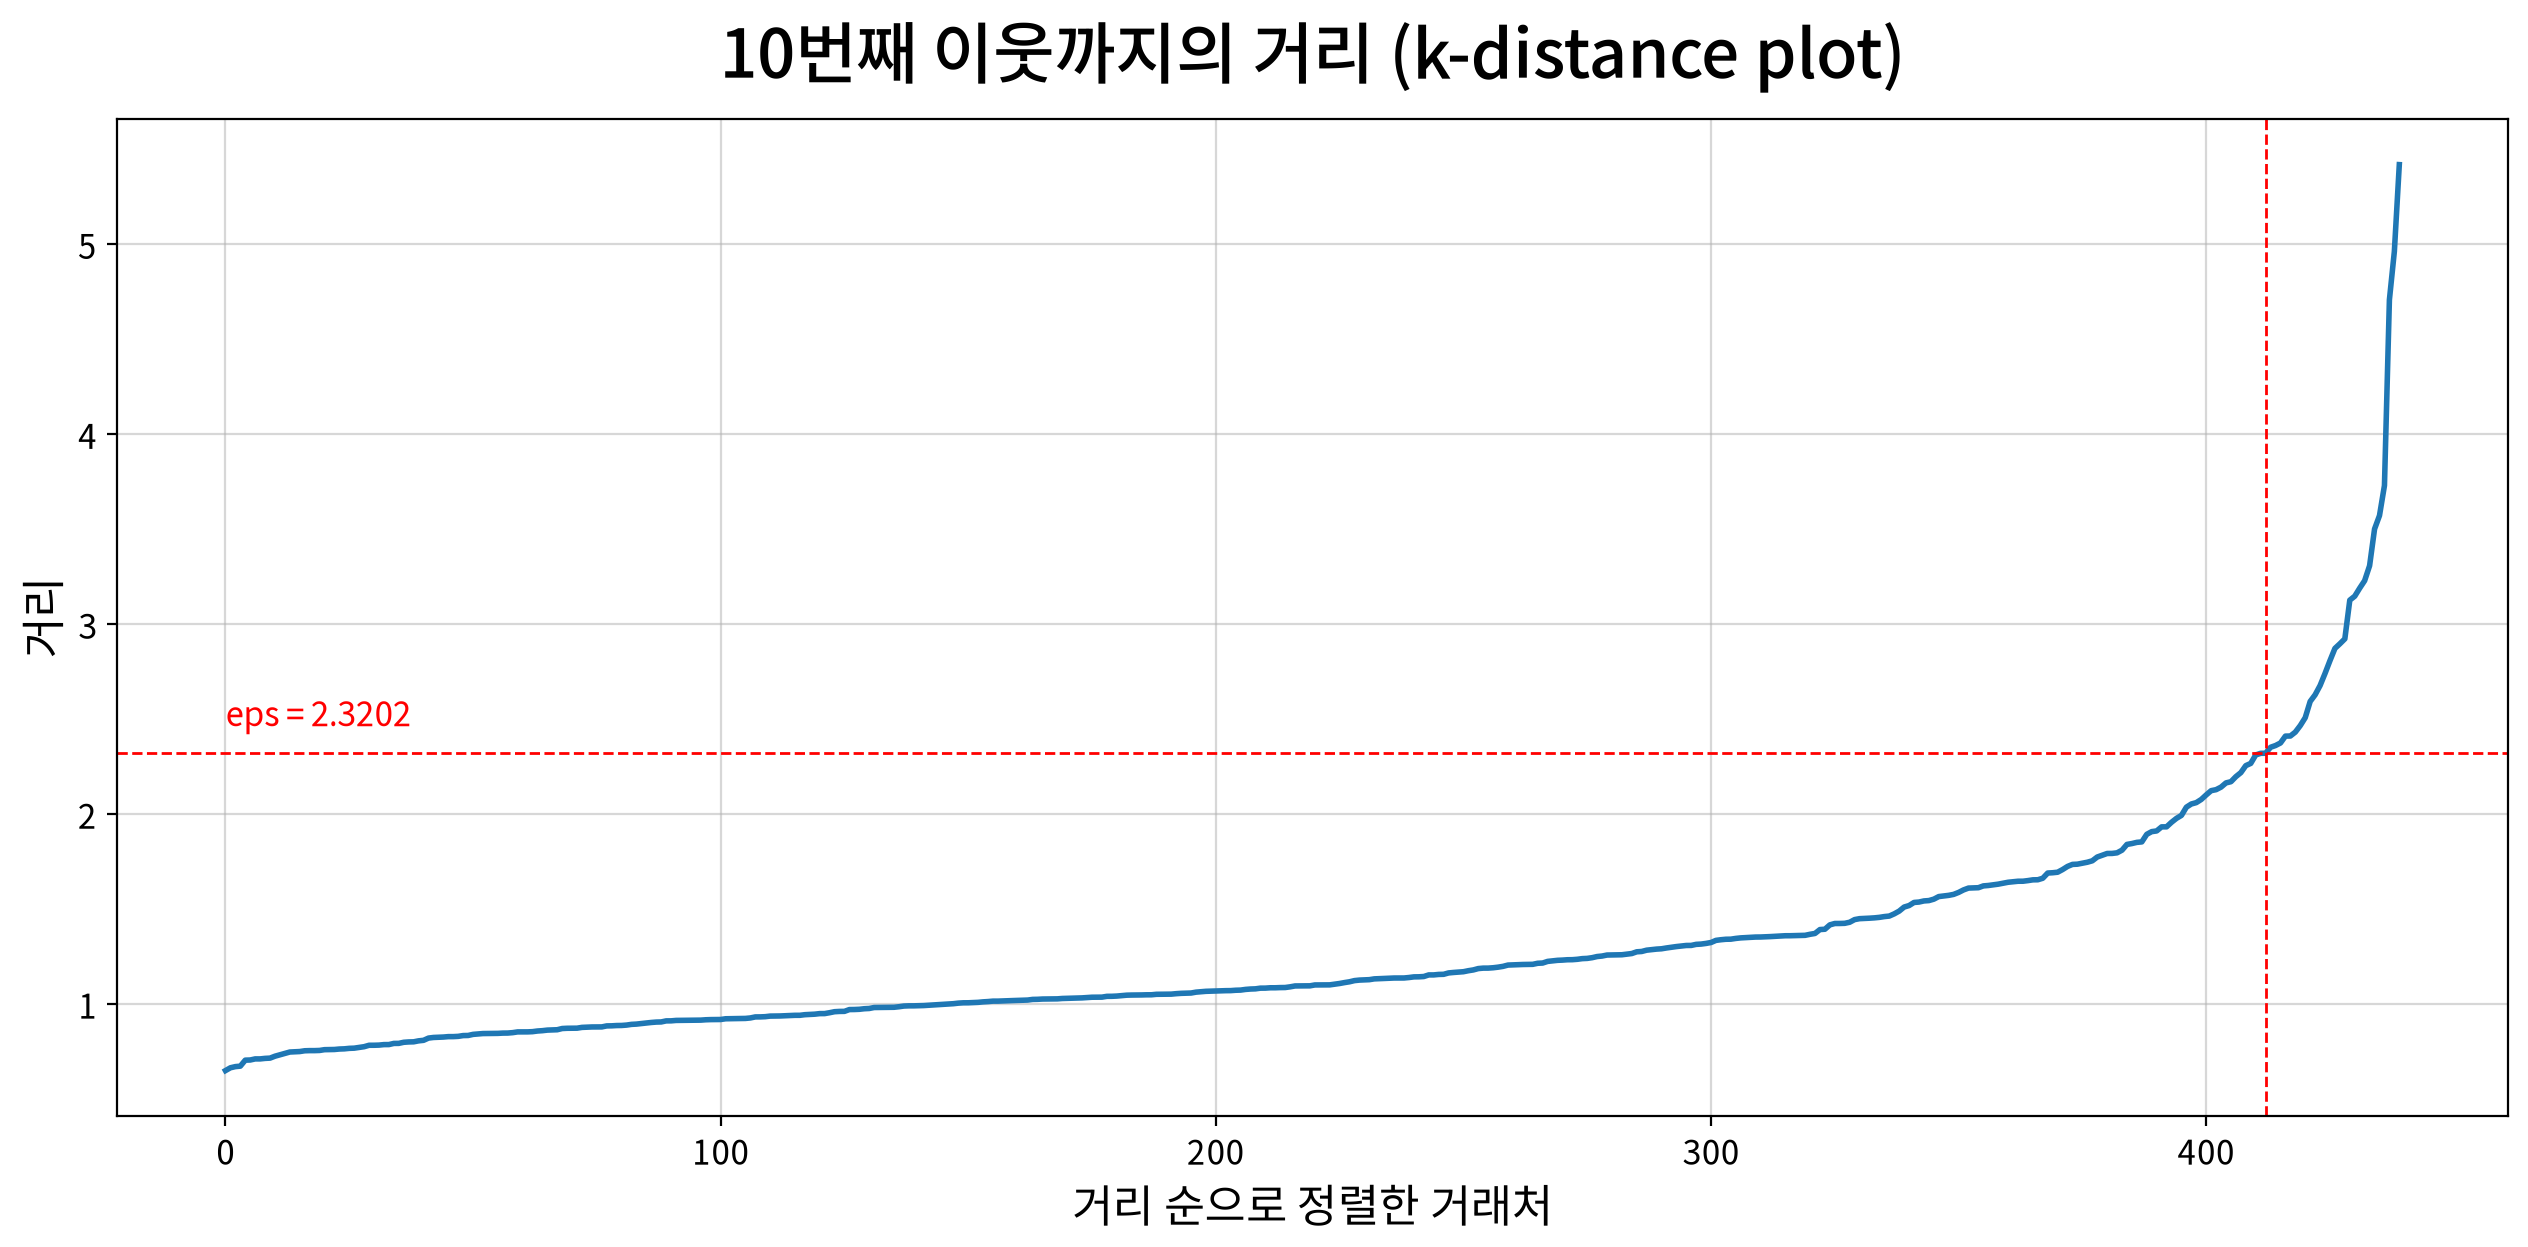

In [15]:
fig, ax = my_plot.init(title=f"{k}번째 이웃까지의 거리 (k-distance plot)",
                       xlabel="거리 순으로 정렬한 거래처", ylabel="거리")

my_plot.lineplot(x=list(range(0, len(target))), y=target, ax=ax)

ax.axhline(eps, color="red", linestyle="--", linewidth=1)
ax.axvline(point, color="red", linestyle="--", linewidth=1)
ax.text(0, eps + 0.1, f"eps = {eps:.4f}", color="red", va="bottom")

my_plot.show()

#### 모듈 함수로 같은 결과 확인

In [16]:
# 위의 세 단계(거리 계산 → 꺾이는 지점 → 시각화)는 함수 한 줄로 대체된다
auto_eps, kdist_df = my_cluster.best_eps(sdf, min_samples=min_samples,
                                         scaling=None, plot=False)

print(f"두 값의 차이: {abs(eps - auto_eps):.10f}")

[k-distance] min_samples = 10, 최적의 eps = 2.3202
  · 꺾이는 위치 = 412번째 데이터 (전체 440개 중)
  · 노이즈 후보 = 27개 (거리가 eps 보다 먼 데이터)
두 값의 차이: 0.0000000000


#### 끌어낸 반경으로 다시 군집화

[DBSCAN] eps = 2.320230233667262, min_samples = 10, 거리 = euclidean
  · 군집 수 = 1개 (노이즈 제외)
  · 노이즈 = 10개 (전체의 2.3%)


,그룹번호,데이터수,비율(%),핵심벡터,외곽벡터
0,-1,10,2.300,0,0
1,0,430,97.700,412,18


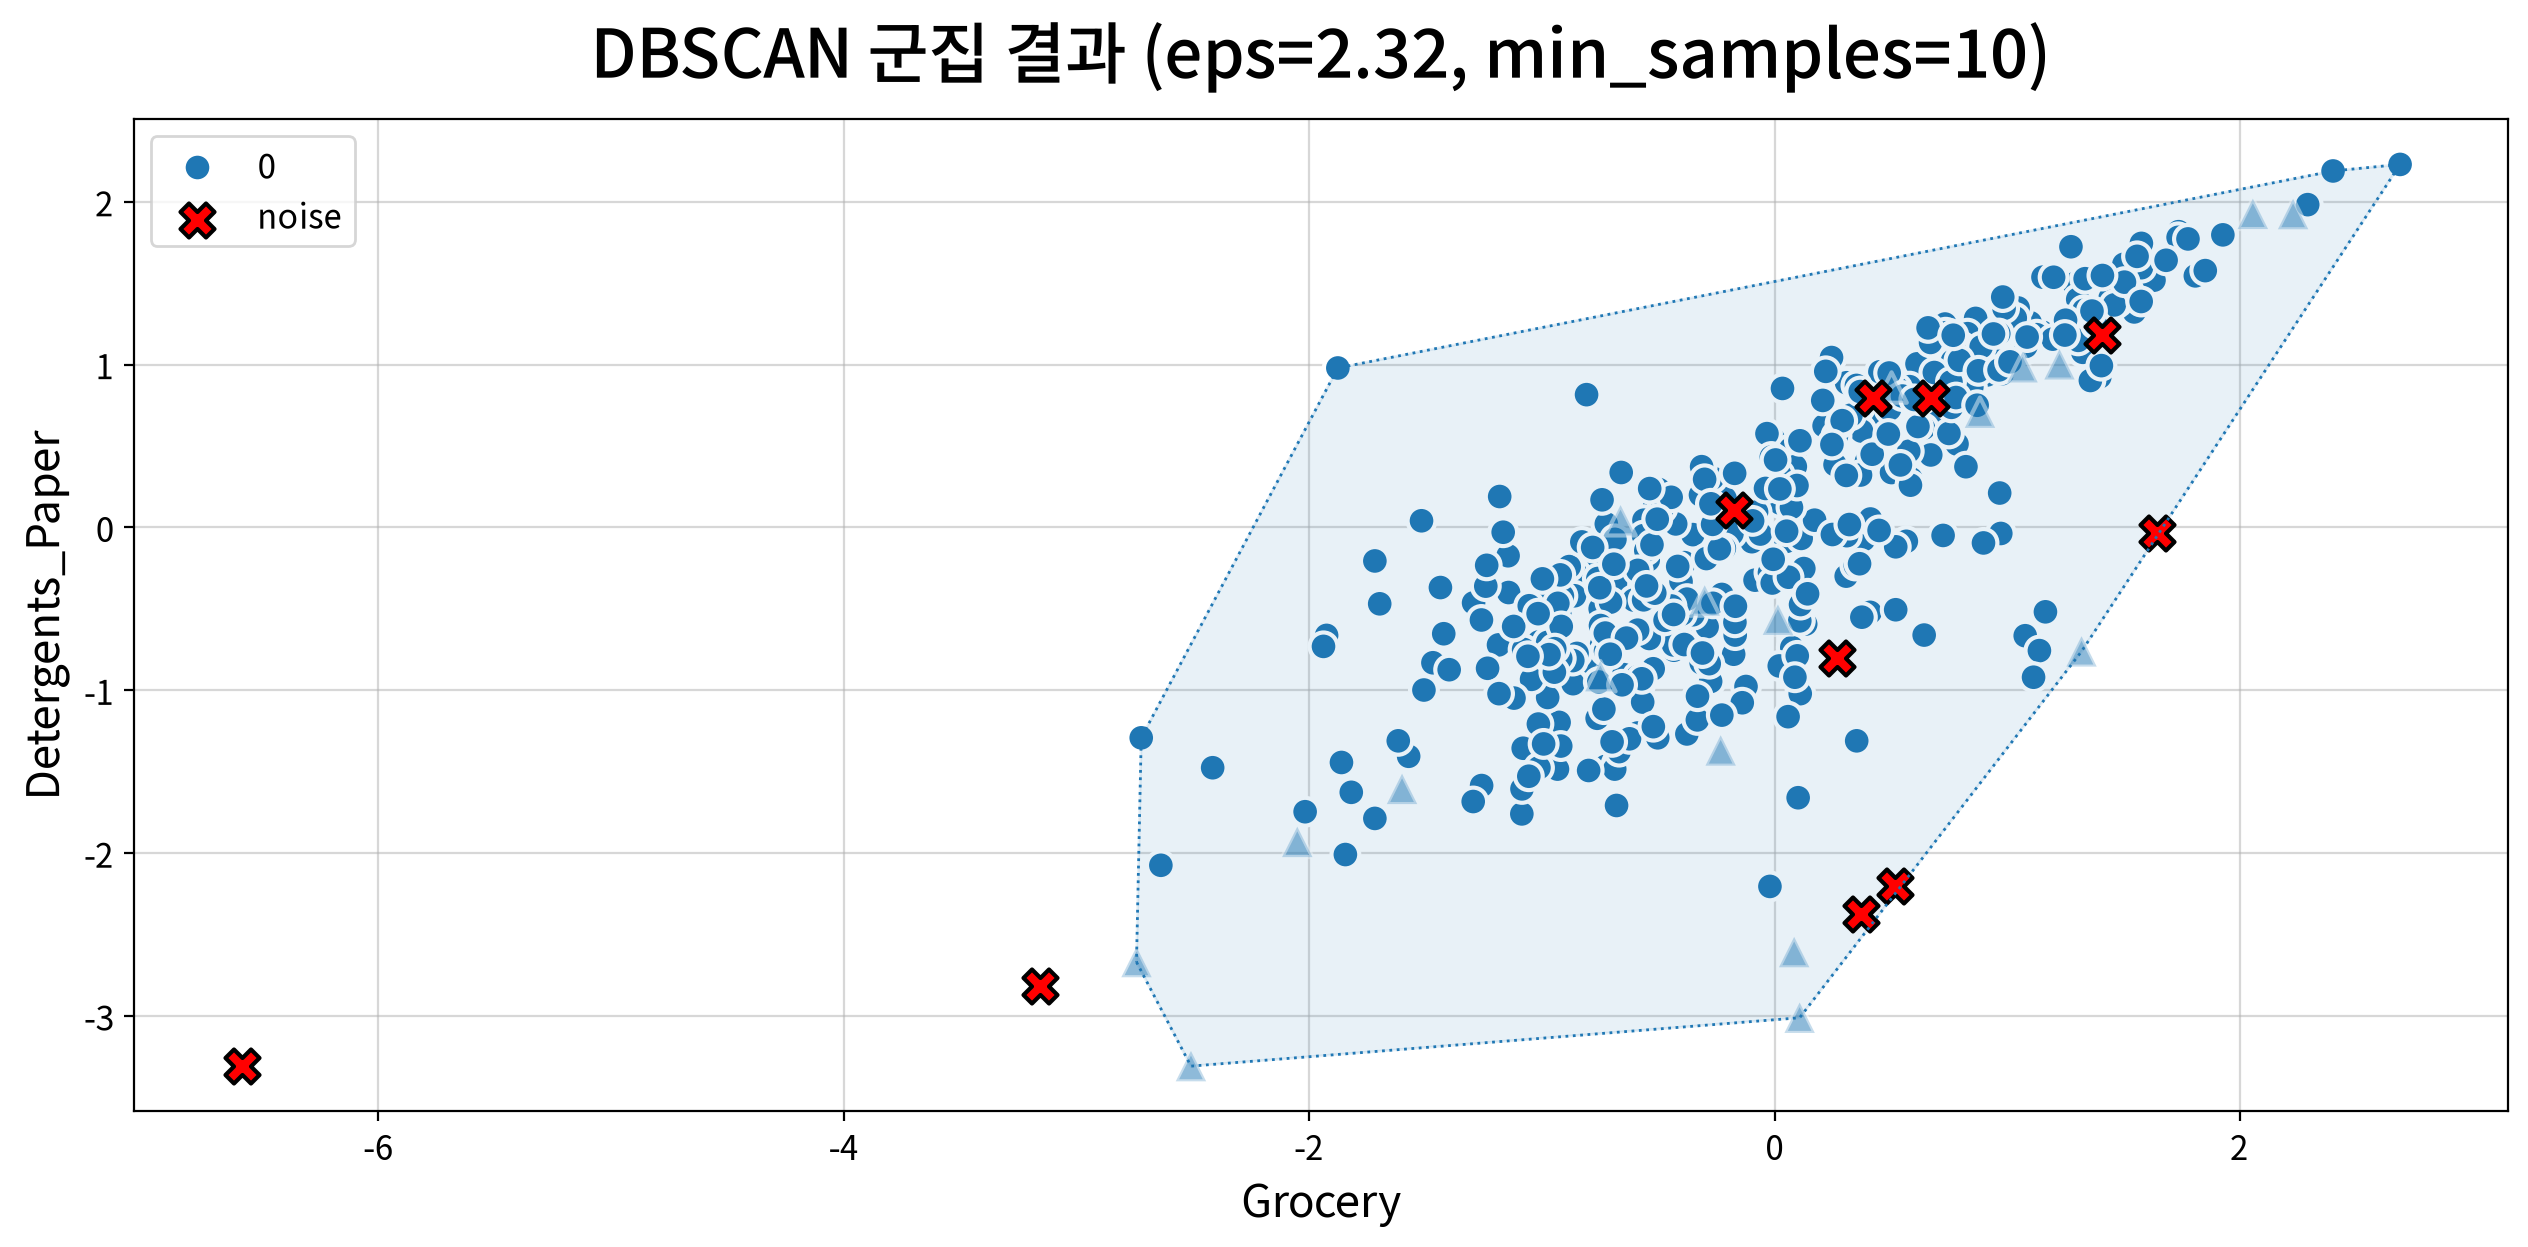

In [17]:
estimator, dbf, summary = my_cluster.dbscan(sdf, eps=eps, min_samples=min_samples,
                                            scaling=None,
                                            x="Grocery", y="Detergents_Paper")

#### 지난번 보고(반경 2.0 / 최소 이웃 5)와 맞대어 보기

In [18]:
estimator0, dbf0, summary0 = my_cluster.dbscan(sdf, eps=2.0, min_samples=5,
                                              scaling=None, verbose=False, plot=False)

print("[지난번 반경 2.0(행) × 이번 반경(열)]")
print(crosstab(dbf0["그룹번호"], dbf["그룹번호"]).to_string())

score = adjusted_rand_score(dbf0["그룹번호"], dbf["그룹번호"])
print(f"\n두 결과의 일치도: {score:.4f}")

[지난번 반경 2.0(행) × 이번 반경(열)]
그룹번호  -1    0
그룹번호         
-1    10    5
 0     0  425

두 결과의 일치도: 0.7848


### 문제 풀이

#### 1. 이웃이 가장 멀리 떨어져 있는 거래처는 열 곳의 이웃을 채우려면 반경을 얼마까지 벌려야 하나요? (소수 셋째 자리)

- **정답**: `5.420`
- **복습 개념**: 반경을 정하기 전에 "이 데이터에서 이웃까지의 거리는 대체로 얼마인가"를 먼저 봅니다. 각 거래처에서 k번째로 가까운 이웃까지의 거리는 그 거래처 주변이 얼마나 빽빽한지를 나타냅니다. 값이 작으면 무리 한복판, 크면 외톨이입니다.
- **풀이 접근**: 전처리를 마친 440곳에 대해 각 거래처에서 가까운 순으로 열 곳의 이웃을 찾고, 그중 열 번째 이웃까지의 거리만 뽑아 작은 순으로 정렬합니다. 그 배열의 마지막 값이 가장 외톨이인 거래처의 거리입니다.
- **근거(계산 결과)**: 정렬한 거리는 가장 빽빽한 거래처가 0.6492, 중앙값이 1.0978인데 마지막 값은 **5.4196**입니다. 무리 한복판에 있는 거래처보다 여덟 배 넘게 반경을 벌려야 겨우 열 곳을 채운다는 뜻입니다.
- **헷갈리기 쉬운 점**: 이웃을 열 곳 찾으면 그중 자기 자신이 0번째로 들어옵니다. 그래서 마지막 열은 "자기 말고 이웃 열 곳"이 아니라 "자기 포함 열 곳"까지의 거리이며, 이것이 정확히 밀집도 기반 군집화가 무리의 몸통을 판정할 때 쓰는 조건과 같은 계산입니다. 거리 분포가 반경의 근거가 될 수 있는 이유가 여기에 있습니다.

#### 2. 그 거리들을 작은 순으로 늘어놓으면 끝부분에서 급격히 치솟습니다. 치솟기 직전의 꺾이는 지점에서 읽어낸 반경은 얼마인가요? (소수 셋째 자리)

- **정답**: `2.320`
- **복습 개념**: 이번 단원의 핵심입니다. 정렬한 거리 곡선에서 완만하던 선이 갑자기 가팔라지는 지점이 "여기서부터는 이웃이 유난히 멀다"는 경계입니다. 그 지점의 거리를 반경으로 삼으면 빽빽한 자리만 무리로 묶이고 나머지는 걸러집니다.
- **풀이 접근**: 정렬한 거리를 y축, 그 순서를 x축으로 놓은 곡선에서 꺾이는 지점을 찾습니다. 오른쪽 위로 치솟는 모양이므로 아래로 볼록하면서 우상향하는 곡선으로 지정해야 합니다. 찾아낸 지점의 y좌표, 즉 거리 값이 반경입니다.
- **근거(계산 결과)**: 꺾이는 지점은 440곳 중 412번째이고, 그 지점의 거리는 **2.3202**입니다. 지난번 눈대중으로 고른 2.0과 크게 다르지 않지만, 이번 값은 노이즈 비율을 몇 퍼센트로 잡느냐와 무관하게 데이터의 거리 분포 자체에서 나온 값입니다.
- **자주 하는 실수**: 꺾이는 지점을 찾을 때 x좌표와 y좌표를 바꿔 답하기 쉽습니다. 여기서 필요한 값은 "몇 번째 거래처인가"(412)가 아니라 "그 지점의 거리가 얼마인가"(2.3202)입니다. 곡선의 모양을 우하향으로 잘못 지정하면 아예 다른 지점이 잡히거나 아무것도 찾지 못한다는 점도 함께 기억하세요.

#### 3. 그 반경으로 다시 나눴을 때, 반경 안에 최소 이웃 수를 채워 무리의 몸통을 이루는 거래처는 몇 곳인가요? (곳)

- **정답**: `412`
- **복습 개념**: 무리에 속한 데이터는 다시 둘로 갈립니다. 자기 반경 안에 최소 이웃 수를 채운 곳이 핵심 벡터, 스스로는 못 채우지만 핵심 벡터의 반경 안에 들어와 무리에 얹혀 있는 곳이 외곽 벡터입니다.
- **풀이 접근**: 앞에서 끌어낸 반경과 고정해 둔 최소 이웃 수로 군집화한 뒤, 요약표에서 핵심 벡터의 개수를 읽습니다.
- **근거(계산 결과)**: 요약표에서 0번 무리 430곳은 핵심 벡터 **412곳**과 외곽 벡터 18곳으로 나뉩니다. 이 412는 앞 문항에서 확인한 꺾이는 위치 412번째와 같은 숫자입니다. 우연이 아니라, 꺾이는 지점 아래쪽에 놓인 거래처들이 곧 반경 안에 이웃을 채운 곳이기 때문입니다.
- **함께 생각해 볼 점**: 반경보다 이웃이 멀리 있는 거래처는 27곳인데 실제로 걸러진 곳은 10곳뿐입니다. 나머지는 자기 반경 안에 열 곳을 못 채웠지만 핵심 벡터의 반경 안에 들어와 있어 외곽 벡터로 무리에 남았습니다. "거리가 반경보다 멀다"와 "노이즈다"는 같은 말이 아닙니다.

#### 4. 지난 보고에서는 어디에도 속하지 못한 거래처가 15곳이었습니다. 근거를 갖춰 반경을 다시 정한 이번에는 몇 곳인가요? (곳)

- **정답**: `10`
- **복습 개념**: 반경과 최소 이웃 수를 바꾸면 걸러지는 데이터도 달라집니다. 두 값은 따로 노는 것이 아니라 함께 움직이며, 최소 이웃 수를 5에서 10으로 올리면 조건이 빡빡해지지만 반경이 2.0에서 2.32로 넓어지면 조건이 느슨해집니다.
- **풀이 접근**: 이번 반경으로 군집화한 결과에서 군집 번호가 -1인 거래처의 개수를 셉니다. 지난번 결과와 나란히 놓고 비교합니다.
- **근거(계산 결과)**: 이번 결과는 노이즈 **10곳**(전체의 2.3%)이고 무리는 여전히 1개입니다. 지난번 15곳에서 5곳이 줄었습니다. 교차표를 보면 이번에 걸러진 10곳은 모두 지난번에도 걸러졌던 곳이며, 지난번 15곳 중 5곳이 이번에는 무리 안으로 돌아왔습니다.
- **실무 포인트**: 이번 10곳은 지난번 15곳의 부분집합입니다. 즉 반경을 바꿔도 끝까지 살아남은 곳이 10곳이라는 뜻이고, 이런 거래처야말로 설정값에 흔들리지 않는 진짜 특이 거래처입니다. 반대로 이번에 무리로 돌아온 5곳은 경계선에 걸쳐 있던 곳이므로 특이 거래처로 보고하기에는 근거가 약합니다.

#### 5. 팀장에게 "결론은 크게 달라지지 않았다"고 보고하려면 두 결과가 얼마나 겹치는지를 수치로 보여야 합니다. 지난번 결과와 이번 결과의 일치도는 얼마인가요? (소수 셋째 자리)

- **정답**: `0.785`
- **복습 개념**: 서로 다른 설정으로 얻은 두 군집 결과가 얼마나 같은지를 재는 지표입니다. 1에 가까울수록 같은 결과, 0이면 우연히 겹친 수준, 음수면 우연보다도 안 맞는다는 뜻입니다. 무리 번호가 뒤바뀌어도 값이 흔들리지 않으므로 두 결과를 직접 맞대어 볼 때 씁니다.
- **풀이 접근**: 지난번 설정(반경 2.0, 최소 이웃 5)으로 한 번, 이번에 끌어낸 설정으로 한 번 군집화해 두 벌의 군집 번호를 만든 뒤 그 일치도를 계산합니다.
- **근거(계산 결과)**: 일치도는 **0.7848**입니다. 440곳 중 435곳은 두 결과에서 같은 자리에 놓였고, 다른 곳은 지난번에만 걸러졌던 5곳뿐입니다. 그런데도 값이 1이 아니라 0.78까지 내려간 것은 걸러진 데이터가 워낙 소수라 다섯 곳의 이동이 크게 반영되기 때문입니다.
- **결론**: 팀장에게 드릴 답은 이렇습니다. 데이터의 거리 분포에서 끌어낸 반경은 2.32로, 눈대중으로 고른 2.0과 사실상 같은 자리를 가리켰습니다. 지난 보고의 결론이 뒤집힌 것은 아니라는 뜻입니다. 다만 특이 거래처 명단은 15곳에서 10곳으로 좁혀야 합니다. 이 10곳은 반경을 어떻게 잡든 끝까지 걸러진 곳이므로 개별 관리 대상으로 올릴 근거가 충분하고, 나머지 5곳은 경계선에 걸쳐 있으므로 명단에서 내리는 것이 맞습니다. 이제 반경은 "노이즈 비율 5%"라는 임의의 기준이 아니라 거리 분포가 꺾이는 지점이라는 근거를 갖게 되었습니다.